# RAG Agent (검색 증강 생성 에이전트)

**RAG (Retrieval-Augmented Generation)** 는 외부 지식 소스에서 정보를 검색하여 LLM의 응답을 향상시키는 기술입니다.

RAG 에이전트는 검색 도구를 사용하여 관련 문서를 찾고, 이를 컨텍스트로 활용하여 답변을 생성합니다.

**참고**: [LangChain 공식 문서 - RAG Agent](https://docs.langchain.com/oss/python/langchain/rag)

## RAG 워크플로우

1. **인덱싱 (Indexing)**: 문서를 로드, 분할, 임베딩하여 벡터 스토어에 저장
2. **검색 및 생성 (Retrieval & Generation)**: 사용자 질문에 대해 관련 문서를 검색하고 답변 생성

에이전트가 필요할 때만 검색 도구를 호출합니다.
- 장점: 유연성, 필요할 때만 검색
- 단점: 여러 번의 모델 호출로 인한 지연 시간

In [4]:
# 필요한 라이브러리 설치 (Colab 등에서 최초 1회 실행)
!pip install -q -U langchain langchain-google-genai langchain-community beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 모델 및 임베딩 초기화 (Gemini 사용)
model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# 벡터 스토어 생성
vector_store = InMemoryVectorStore(embeddings)

## 1. 인덱싱 단계

문서를 로드하고 벡터 스토어에 저장합니다.

### 1.1 문서 로드 및 분할

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 웹 문서 로드
loader = WebBaseLoader("https://botpress.com/ko/blog/llm-agents")
docs = loader.load()

print(f"로드된 문서 수: {len(docs)}")
print(f"문서 길이: {len(docs[0].page_content)} 문자")

# 텍스트 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

all_splits = text_splitter.split_documents(docs)
print(f"\n분할된 청크 수: {len(all_splits)}")

로드된 문서 수: 1
문서 길이: 9541 문자

분할된 청크 수: 17


### 1.2 벡터 스토어에 저장

In [4]:
# 문서를 벡터 스토어에 추가
document_ids = vector_store.add_documents(documents=all_splits)
print(f"저장된 문서 ID 수: {len(document_ids)}")

저장된 문서 ID 수: 17


### 2. 체인 기반 RAG (Chain-based RAG)

검색을 먼저 실행하고 검색 결과를 LLM에 컨텍스트로 제공

In [5]:
# 체인 기반 RAG 예제
from langchain_core.messages import HumanMessage

def chain_based_rag(query: str):
    """체인 기반 RAG: 항상 검색 후 답변 생성"""
    # 1. 검색
    retrieved_docs = vector_store.similarity_search(query, k=2)
    context = "\n\n".join(doc.page_content for doc in retrieved_docs)

    # 2. 컨텍스트와 함께 답변 생성
    messages = [
        HumanMessage(content=f"""다음 컨텍스트를 참고하여 질문에 답변하세요:

컨텍스트:
{context}

질문: {query}

답변:""")
    ]

    response = model.invoke(messages)
    return response.content

# 체인 기반 RAG 테스트
query = "에이전트의 주요 특징은?"
print(f"질문: {query}\n")
answer = chain_based_rag(query)
print(f"답변: {answer}")

질문: 에이전트의 주요 특징은?

답변: 컨텍스트에 따르면, LLM 에이전트의 핵심 특징은 다음과 같습니다:

1.  **언어 모델 (Language Model):** LLM 에이전트의 '두뇌'로, 맥락을 이해하고 패턴을 인식하며 일관성 있고 상황에 맞는 답변을 생성합니다.
2.  **메모리 (Memory):** 과거 상호작용에서 얻은 정보(사실, 사용자 선호, 세션 간 주제 등)를 기억하여 대화를 더 자연스럽고 연속적으로 만듭니다.
3.  **도구 활용 (Tool Utilization):** 외부 애플리케이션, 데이터베이스, API와 연동하여 특정 기능을 수행하고 실제 행동으로 확장시킵니다.

(제공된 컨텍스트에서는 4가지 특징 중 3가지가 설명되어 있습니다.)


### 3. 에이전트 기반 RAG (Agentic RAG)

### 3.1 검색 도구 생성

In [6]:
from langchain.tools import tool

@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """질문에 답하기 위해 관련 정보를 검색합니다.

    이 도구는 벡터 스토어에서 질문과 관련된 문서를 검색합니다.
    검색된 문서는 답변 생성에 사용됩니다.

    Args:
        query: 검색할 질문 또는 키워드
    """
    # 벡터 스토어에서 유사한 문서 검색
    retrieved_docs = vector_store.similarity_search(query, k=2)

    # 검색된 문서를 문자열로 직렬화
    serialized = "\n\n".join(
        f"출처: {doc.metadata.get('source', 'N/A')}\n내용: {doc.page_content}"
        for doc in retrieved_docs
    )

    # 문자열과 문서 객체를 함께 반환
    return serialized, retrieved_docs

# 도구 테스트
test_result = retrieve_context.invoke("LLM 에이전트의 구성 요소")
test_result

'출처: https://botpress.com/ko/blog/llm-agents\n내용: 수 있지만, 개인정보 보호와 관련성 유지를 위해 종종 규제됩니다.3. 도구 활용도구 활용은 LLM 에이전트를 단순 대화에서 실제 행동으로 확장시킵니다.LLM 에이전트는 외부 애플리케이션, 데이터베이스, API와 연동해 특정 기능을 수행할 수 있습니다.즉, 실시간 정보를 가져오거나 외부 작업을 실행하거나 특화된 데이터베이스에 접근할 수 있어, 실시간 정보 제공이 가능합니다. 예시는 다음과 같습니다.API 호출날씨 정보나 주가 등 실시간 데이터 가져오기회의나 약속 일정 잡기상품 카탈로그나 인사 정책 문서 등 데이터베이스 질의도구 활용을 통해 LLM 에이전트는 지식 기반 시스템에서 벗어나, 다른 시스템과 상호작용하는 능동적 주체가 됩니다.4. 계획 수립계획 수립은 LLM 에이전트가 복잡한 작업을 여러 단계로 나누어 처리하는 능력입니다.LLM 에이전트는 피드백 유무에 따라 계획을 세울 수 있습니다. 차이점은 무엇일까요?피드백 없이 계획을 세우면, LLM 에이전트는 초기 이해를 바탕으로 계획을 수립합니다. 더 빠르고 단순하지만, 적응력이 떨어집니다.피드백 과 함께 계획을 세우면, LLM 에이전트는 환경에서 입력을 받아 계획을 지속적으로 수정할 수 있습니다. 더 복잡하지만, 훨씬 유연하고 시간이 지날수록 성능이 향상됩니다.계획 수립을 통해 LLM 에이전트는 논리적인 흐름을 만들어 복잡한 요청도 효과적으로 처리할 수 있습니다.LLM 에이전트의 4가지 유형은 무엇인가요?1. 대화형 에이전트 (예: 고객 지원 및 리드 생성)이 에이전트는 사용자와 자연스러운 대화를 나누며, 정보를 제공하거나 질문에 답하고 다양한 작업을 지원합니다.이들은 LLM을 활용해 인간과 유사한 답변을 이해하고 생성합니다.예시: 고객 지원 에이전트, 헬스케어 챗봇2. 작업 지향 에이전트 (예: AI 비서 및 AI 워크플로우)특정 작업 수행이나 미리 정해진 목표 달성에 집중하는 에이전트로, 사용자의 요구를 파악한 뒤 이

### 3.2 RAG 에이전트 생성

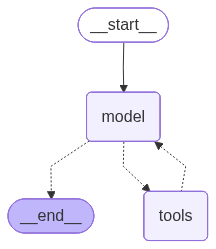

In [7]:
from langchain.agents import create_agent

# 시스템 프롬프트 설정
system_prompt = (
    "당신은 블로그 게시글에서 관련 문맥(context)을 검색하는 도구에 접근할 수 있습니다. "
    "사용자의 질문에 답하기 위해 먼저 retrieve_context 도구를 사용하여 관련 정보를 검색한 후, "
    "검색된 정보를 바탕으로 정확하고 유용한 답변을 제공하세요."
)

# 에이전트 생성
agent = create_agent(
    model,
    tools=[retrieve_context],
    system_prompt=system_prompt
)

agent

### 3.3 에이전트 실행

In [10]:
# 질문에 대한 답변 생성
query = "LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?"
# query = "에이전트의 주요 특징은 무엇인가요?"
# query = "프롬프트 엔지니어링이 중요한 이유는 무엇인가요?"

print(f"질문: {query}\n")
print("=" * 80)

# 스트리밍 방식으로 실행
for event in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

질문: LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?

================================ Human Message =================================

LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?
================================== Ai Message ==================================
Tool Calls:
  retrieve_context (4a6a3311-f0ef-44d1-9e13-ddc348599e3d)
 Call ID: 4a6a3311-f0ef-44d1-9e13-ddc348599e3d
  Args:
    query: LLM 에이전트 프레임워크의 핵심 구성 요소
================================= Tool Message =================================
Name: retrieve_context

출처: https://botpress.com/ko/blog/llm-agents
내용: ‍이러한 기능이 결합되어 LLM 에이전트는 복잡하고 다단계의 워크플로우도 완전히 자율적으로 처리할 수 있습니다.예를 들어:B2B 영업 에이전트는 CRM에서 잠재 고객 데이터를 검색하고, 거래 진행 상황을 분석하며, 과거 상호작용을 기억해 맞춤형 후속 조치를 취하고, 이메일과 캘린더 API를 활용해 발송 및 일정을 잡습니다.IT 에이전트는 시스템 로그를 검색해 오류를 진단하고, 문제 해결 단계를 분석하며, 이전 사용자 이슈에서 효과적이었던 방법을 기억하고, 스크립트를 실행해 서비스를 재시작하거나 티켓을 생성합니다.LLM 에이전트를 정의하는 4가지 특징은 무엇인가요?LLM 에이전트의 핵심 특징 네 가지는 다음과 같습니다.1. 언어 모델언어 모델은 LLM 에이전트의 ‘두뇌’로 여겨집니다. 모델의 품질과 규모가 LLM 에이전트의 성능에 직접적인 영향을 미칩니다.방대한 텍스트 데이터로 학습

## 주요 포인트 정리

1. **인덱싱**: 문서 로드 → 분할 → 임베딩 → 벡터 스토어 저장
2. **검색 도구**: 벡터 스토어를 래핑한 도구 생성
3. **에이전트 통합**: 검색 도구를 에이전트에 추가
4. **에이전트 기반 vs 체인 기반**: 필요에 따라 선택